# Global Layoffs Analysis

## Executive Summary

This project analyzes a global layoffs dataset to identify trends and patterns in workforce reductions across companies, industries, and countries. The objective is to explore the data, perform appropriate data cleaning, answer key business questions, and communicate meaningful insights through exploratory data analysis and data visualization.

The analysis aims to uncover which companies and industries experienced the largest layoffs, how layoffs varied across different countries and years, and whether factors such as company stage, funding, or location were associated with workforce reductions. The findings will demonstrate practical data analysis skills using Python and the Pandas library while applying a structured analytical workflow similar to that used in professional data analytics projects.

## Project Objectives

The objectives of this project are to:

- Inspect the dataset to understand its structure and contents.
- Clean the dataset by handling missing values, duplicate records, and inconsistent data where necessary.
- Explore the data to identify trends and patterns in global layoffs.
- Analyze layoffs across companies, industries, countries, and time periods.
- Generate meaningful business insights supported by data.
- Present the findings using clear visualizations and professional documentation.

In [2]:
import pandas as pd

### Data Inspection 

In [3]:
df = pd.read_csv("layoffs.csv")

In [3]:
df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,GoKwik,"New Delhi, Non-U.S.",100.0,7/11/2026,NaN,Finance,https://inc42.com/buzz/exclusive-gokwik-lays-o...,Unknown,68.0,India,7/12/2026
1,MyHeritage,"Tel Aviv, Non-U.S.",500.0,7/8/2026,0.15,Consumer,https://en.globes.co.il/en/article-myheritage-...,Acquired,49.0,Israel,7/9/2026
2,OpenText,"Waterloo, Non-U.S.",400.0,7/8/2026,0.02,Data,https://betakit.com/opentext-lays-off-two-perc...,Post-IPO,1100.0,Canada,7/10/2026
3,Mews,"Amsterdam, Non-U.S.",200.0,7/7/2026,0.15,Travel,https://skift.com/2026/07/07/mews-layoffs-rest...,Series D,817.0,Netherlands,7/8/2026
4,Darrow,"Tel Aviv, Non-U.S.",60.0,7/7/2026,0.33,Legal,https://www.calcalistech.com/ctechnews/article...,Series B,63.0,Israel,7/8/2026


In [ ]:
df.info()

In [ ]:
df.shape

In [4]:
df.columns

Index(['company', 'location', 'total_laid_off', 'date', 'percentage_laid_off',
       'industry', 'source', 'stage', 'funds_raised', 'country', 'date_added'],
      dtype='object')

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

## Data Cleaning

Data cleaning is an essential step before analysis. In this section, the dataset is examined for data quality issues such as duplicate records, missing values, inconsistent entries, and incorrect data types. Appropriate cleaning techniques are then applied to improve the accuracy and consistency of the analysis.

In [5]:
#convert our original df into a new copy as clean_df variable for cleansing
clean_df = df.copy()

In [ ]:
#tells you how many missing values there are in each column?
clean_df.isnull().sum()

In [ ]:
# tells you where the missing values for location column?
clean_df[clean_df["location"].isnull()]

In [ ]:
# tells you where the missing values for country column?
clean_df[clean_df["country"].isnull()]

In [ ]:
# tells you where the missing values for industry column?
clean_df[clean_df["industry"].isnull()]

In [ ]:
# tells you where the missing values for source column?
clean_df[clean_df["source"].isnull()]

In [ ]:
# tells you where the missing values for stage column?
clean_df[clean_df["stage"].isnull()]

In [ ]:
# tells you where the missing values for percentage laid_off_column?
clean_df[clean_df["percentage_laid_off"].isnull()]

In [ ]:
# tells you where the missing values for total_laid_off column?
clean_df[clean_df["total_laid_off"].isnull()]

In [ ]:
# tells you where the missing values for fund_raised column?
clean_df[clean_df["fund_raised"].isnull()]

##### Handling Missing Values

Before replacing missing values, each affected record was inspected individually. Where the missing information could be confidently inferred from other columns or publicly available company information, the missing value was filled. Otherwise, the missing value was retained to avoid introducing unsupported assumptions into the dataset.

In [ ]:
#clean the country column where missing values by filling it accurate value "Germany & Canada"

clean_df.loc[
    clean_df["location"] == "Berlin, Non-U.S.","country"] = "Germany"

clean_df.loc[
    clean_df["location"] == "Montreal, Non-U.S.","country"] = "Canada"

#verify if it has been applied
clean_df["country"].isnull().sum()

In [ ]:
#clean the location column where missing values by filling it accurate value "SF Bay Area"
clean_df.loc[
    clean_df["company"] == "Product Hunt","location"] = "SF Bay Area"

#verify if it has been applied
clean_df["location"].isnull().sum()

In [ ]:
#clean the industry column where missing values by filling it "other" 
clean_df["industry"] = clean_df["industry"].fillna("Other")

#verify if it has been applied
clean_df["industry"].isnull().sum()

In [ ]:
#clean the source column where missing values by filling it with "unkmown"
clean_df["source"] = clean_df["source"].fillna("Unknown")

#verify if it has been applied
clean_df["source"].isnull().sum()

In [ ]:
#clean the stage column where missing values by filling it with "unkmown"
clean_df["stage"] = clean_df["stage"].fillna("Unknown")

#verify if it has been applied
clean_df["stage"].isnull().sum()

The missing values in the `total_laid_off`, `percentage_laid_off`, and `funds_raised` columns were retained because they represent unavailable or undisclosed information. Replacing them with estimated values could introduce bias and affect the accuracy of the analysis.

In [6]:
#changing the date from default as string to real pandas datetime for easier analysis
clean_df["date"] = pd.to_datetime(clean_df["date"])

#verify if it has been converted (the Dtype must show datetime)
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4507 entries, 0 to 4506
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company              4507 non-null   object        
 1   location             4506 non-null   object        
 2   total_laid_off       2951 non-null   float64       
 3   date                 4507 non-null   datetime64[ns]
 4   percentage_laid_off  2828 non-null   float64       
 5   industry             4505 non-null   object        
 6   source               4504 non-null   object        
 7   stage                4502 non-null   object        
 8   funds_raised         3978 non-null   float64       
 9   country              4505 non-null   object        
 10  date_added           4507 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(7)
memory usage: 387.4+ KB


In [92]:
#the clean dataset should be exported & saved
clean_df.to_csv("cleaned_global_layoffs.csv", index=False)

## Exploratory Data Analysis (EDA)

The cleaned dataset was explored to identify trends, patterns, and relationships in global layoffs by answering a series of business questions.


#### Question 1

How many employees were laid off in total?

In [ ]:
clean_df["total_laid_off"].sum()

The analysis shows that the companies in this dataset laid off a combined total of **924,124 employees**. This highlights the significant scale of workforce reductions captured in the dataset and provides a foundation for exploring which companies, industries, countries, and time periods contributed the most to these layoffs.

#### Question 2

Which company laid off the most employees?


In [ ]:
clean_df.loc[clean_df["total_laid_off"].idxmax()]

The analysis shows that **Intel** recorded the largest single layoff event in the dataset, laying off **22,000 employees** in **April 2025**. This occurred while the company was in the **Post-IPO** stage and operating within the **Hardware** industry, highlighting one of the most significant workforce reductions captured in the dataset.

#### Question 3

Which industry experienced the most layoffs?

In [ ]:
clean_df.groupby("industry")["total_laid_off"].sum().sort_values(ascending=False)

The analysis shows that the **Other** industry category recorded the highest total layoffs, with **115,835** employees affected. However, this category includes companies that could not be classified into a specific industry during data cleaning. Excluding the **Other** category, the **Retail** industry experienced the highest number of layoffs (**106,763**), followed by **Hardware** (**104,261**) and **Consumer** (**98,199**). These findings suggest that consumer-facing and technology-related industries were among the most affected sectors in the dataset.

#### Question 4

Which country had the highest number of layoffs?


In [ ]:
clean_df.groupby("country")["total_laid_off"].sum().sort_values(ascending=False)

The analysis shows that the **United States** recorded the highest total number of layoffs, with **654,381 employees** affected. This was significantly higher than any other country in the dataset. **India** recorded the second-highest total layoffs with **67,489 employees**, followed by **Germany** with **32,055 employees**. These findings suggest that the United States experienced the greatest impact from workforce reductions among the countries represented in the dataset.

#### Question 5

Which year recorded the highest layoffs?

In [ ]:
clean_df.groupby(clean_df["date"].dt.year)["total_laid_off"].sum().sort_values(ascending=False)

The analysis shows that **2023** recorded the highest number of layoffs, with **265,660 employees** affected. This was followed by **2022** with **165,269 layoffs** and **2024** with **152,922 layoffs**. The findings indicate that **2023 was the peak year for workforce reductions** in the dataset, representing the most significant period of layoffs across the recorded years.

#### Question 6

Which month had the highest layoffs?

In [ ]:
clean_df.groupby(clean_df["date"].dt.month_name())["total_laid_off"].sum().sort_values(ascending=False)

The analysis shows that **January** recorded the highest number of layoffs, with **158,889 employees** affected. This was followed by **May** with **104,438 layoffs** and **April** with **103,927 layoffs**. These findings suggest that workforce reductions were most concentrated during the early months of the year in the dataset.

#### Question 7

How many companies laid off 100% of their workforce, and which companies were they?

In [ ]:
clean_df.loc[
    clean_df["percentage_laid_off"] == 1,
    "company"
].nunique()

In [ ]:
clean_df.loc[
    clean_df["percentage_laid_off"] == 1,
    "company"
].unique()

The analysis identified **350 unique companies** that laid off **100% of their workforce**, indicating complete workforce reductions. These companies spanned multiple industries and countries, suggesting that full workforce layoffs were not confined to a single sector or region. The findings highlight the widespread impact of business closures or complete organizational restructuring across the dataset.

#### Question 8

Which funding stage experienced the most layoffs?

In [ ]:
clean_df.groupby("stage")["total_laid_off"].sum().sort_values(ascending=False)

The analysis shows that **Post-IPO** companies experienced the highest number of layoffs, with **580,546 employees** affected. This was followed by companies with an **Unknown** funding stage (**82,163 layoffs**) and **Acquired** companies (**74,567 layoffs**). These findings suggest that publicly listed companies accounted for the largest share of workforce reductions in the dataset.

#### Question 9

Which location recorded the highest number of layoffs?

In [ ]:
clean_df.groupby("location")["total_laid_off"].sum().sort_values(ascending=False)

The analysis shows that the **SF Bay Area** recorded the highest total number of layoffs, with **309,325 employees** affected. This was followed by **Seattle** with **108,283 layoffs**, **Austin** with **46,353 layoffs**, and **New York City** with **40,911 layoffs**. These findings suggest that major technology and business hubs experienced the largest workforce reductions in the dataset.

#### Question 10

Which companies experienced the highest number of layoff events?

In [ ]:
clean_df["company"].value_counts().head(10)

The analysis shows that **Amazon** recorded the highest number of layoff events, appearing **20 times** in the dataset. This was followed by **Google** (**18 events**), **Microsoft** (**17 events**), **Salesforce** (**14 events**), and **Meta** (**12 events**). These findings suggest that some large organizations implemented workforce reductions across multiple rounds rather than through a single layoff event.

## Visualization 

#### 1. How did layoffs change from year to year?

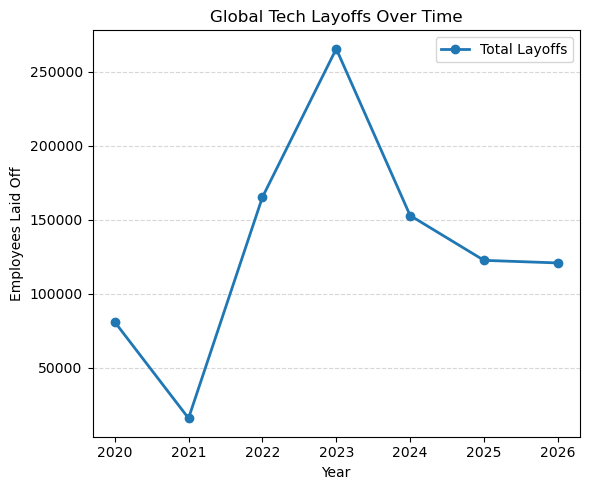

In [11]:
#Line chart

import matplotlib.pyplot as plt

#yearly_variable give us a value that consist of every same year matching the total sum of total_laid_off
yearly_layoffs = (clean_df.groupby(clean_df["date"].dt.year)["total_laid_off"].sum())

#the layout, 6 inches wide and 5 inches tall\height
plt.figure(figsize=(6, 5))

plt.plot( yearly_layoffs.index, yearly_layoffs.values, marker="o", linewidth=2,label="Total Layoffs")

plt.title("Global Tech Layoffs Over Time")

plt.xlabel("Year")

plt.ylabel("Employees Laid Off")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend()

plt.tight_layout()

plt.show()

#### 2. Which industries experienced the most layoffs?

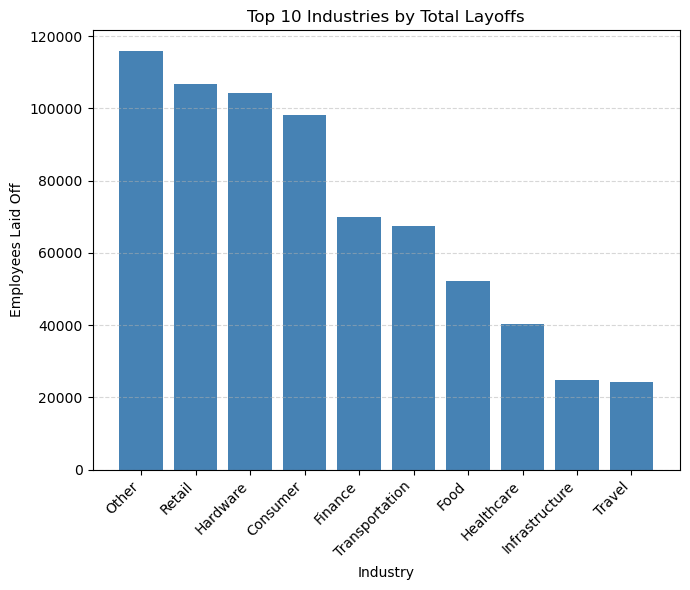

In [17]:
import matplotlib.pyplot as plt

#created industry_layoffs variable that consist of total laid off according to each industry, from highest to lowest
industry_layoffs = (clean_df.groupby("industry")["total_laid_off"].sum().sort_values(ascending=False))

#extracting out 10 head industry frm industry_layoffs
top_10_industries = industry_layoffs.head(10)

#the layout, 7 inches wide and 6 inches tall\height
plt.figure(figsize=(7, 6))

plt.bar(top_10_industries.index,top_10_industries.values,color="steelblue")

plt.title("Top 10 Industries by Total Layoffs")

plt.xlabel("Industry")

plt.ylabel("Employees Laid Off")

# using xticks coz of the label word are too long,rotation=45 tilts the industry names, while ha="right" aligns them so they are easier to read.
plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

#### 3. How large are individual layoff events?

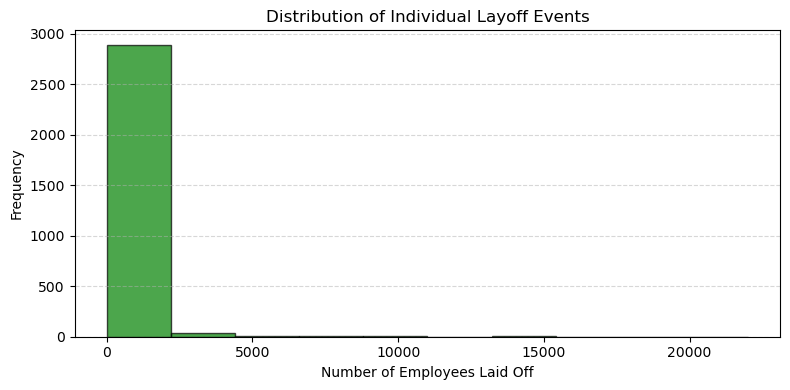

In [29]:
#Histogram

import matplotlib.pyplot as plt

#the layout, 10 inches wide and 6 inches tall\height
#plt.figure(figsize=(8, 4))
plt.figure(figsize=(8, 4))

#plot histogram with age column, seprate the age into 20 intervals, black color and transparency of 0.7
plt.hist(clean_df["total_laid_off"], bins=10, color="green",  edgecolor="black",  alpha=0.7)

plt.title("Distribution of Individual Layoff Events")

plt.xlabel("Number of Employees Laid Off")

plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

#### 4. Which countries recorded the most layoffs?

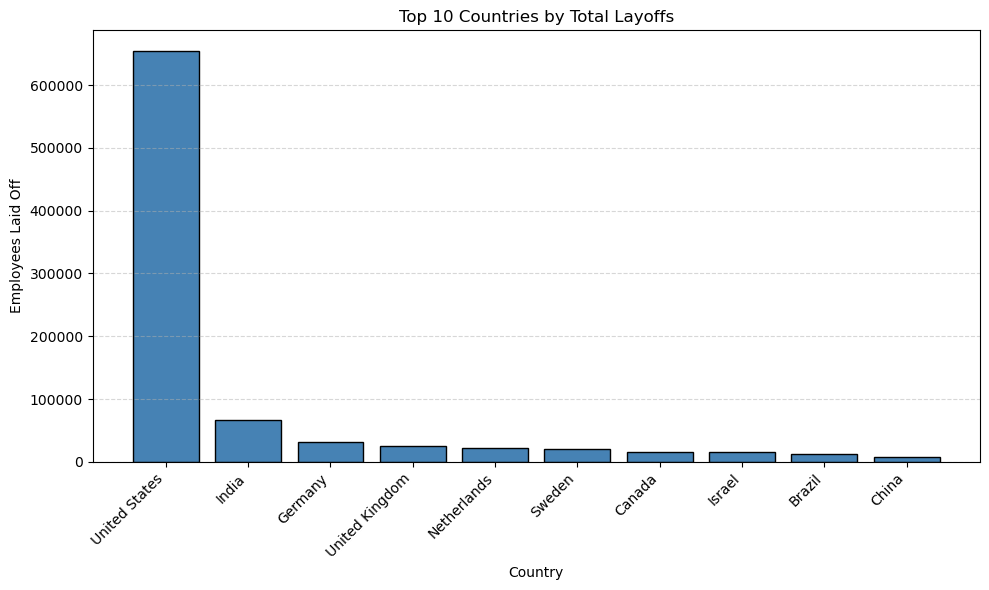

In [30]:
#Bar chart

import matplotlib.pyplot as plt

#created country_layoffs variable that consist of total laid off according to each country, from highest to lowest
country_layoffs = (clean_df.groupby("country")["total_laid_off"].sum().sort_values(ascending=False))

#extracting out 10 head country from country_layoffs
top_10_countries = country_layoffs.head(10)

plt.figure(figsize=(10, 6))

plt.bar(top_10_countries.index, top_10_countries.values,color="steelblue",edgecolor="black")

plt.title("Top 10 Countries by Total Layoffs")

plt.xlabel("Country")

plt.ylabel("Employees Laid Off")

plt.xticks(rotation=45, ha="right")

# using xticks coz of the label word are too long,rotation=45 tilts the industry names, while ha="right" aligns them so they are easier to read.
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

#### 5. Is there a relationship between company size/funding and layoffs?

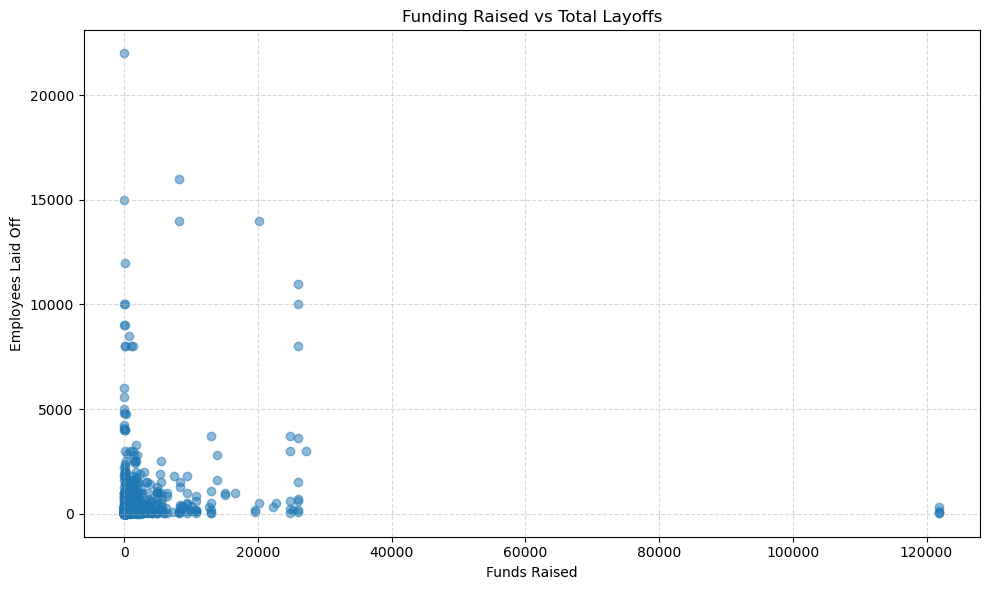

In [31]:
#Scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(clean_df["funds_raised"], clean_df["total_laid_off"], alpha=0.5)

plt.title("Funding Raised vs Total Layoffs")
plt.xlabel("Funds Raised")
plt.ylabel("Employees Laid Off")

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

## Key Insights

- A total of **924,124 employees** were laid off across the companies included in the dataset, highlighting the significant scale of global workforce reductions.

- **Intel** recorded the largest single layoff event, affecting **22,000 employees**.

- The **Retail** industry recorded the highest total layoffs among clearly defined industries, indicating that consumer-facing businesses were heavily impacted.

- The **United States** experienced the highest number of layoffs (**654,381 employees**), while the **SF Bay Area** recorded the highest layoffs among all locations.

- **2023** was the peak year for layoffs, with **265,660 employees** affected, while **January** recorded the highest number of layoffs among all months.

- **Post-IPO** companies accounted for the largest share of layoffs, suggesting that publicly listed companies experienced substantial workforce reductions.

- **350 unique companies** laid off **100% of their workforce**, indicating that complete business shutdowns or full workforce reductions occurred across multiple industries and countries.

- **Amazon** recorded the highest number of layoff events (**20**), followed by **Google**, **Microsoft**, **Salesforce**, and **Meta**, suggesting that several large technology companies implemented multiple rounds of layoffs rather than a single workforce reduction.

## Business Recommendations

Based on the findings from this analysis, the following recommendations are proposed:

- Companies should strengthen workforce planning and financial forecasting to reduce the need for repeated large-scale layoffs.
- Organizations should prioritize employee reskilling and internal mobility before implementing workforce reductions.
- Investors should closely monitor companies experiencing frequent layoff events, as repeated layoffs may indicate ongoing operational or financial challenges.
- Policymakers should provide targeted support for regions and industries with consistently high layoff rates through employment and retraining programs.
- Businesses should regularly monitor economic and industry trends to identify potential risks early and develop proactive workforce strategies.

## Conclusion

This project analyzed global layoff trends using a cleaned dataset containing information on companies, industries, countries, locations, funding stages, and layoff events. Through exploratory data analysis, several key patterns were identified, including the industries, countries, and locations most affected by layoffs, the peak periods of workforce reductions, and companies that experienced repeated or complete workforce layoffs.

The analysis demonstrates how Python and Pandas can be used to transform raw business data into meaningful insights that support data-driven decision-making. Overall, this project highlights the importance of exploratory data analysis in understanding workforce trends and identifying patterns that can inform business strategy and policy decisions.